In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)

In [2]:
os.makedirs("../data/cleaned", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [3]:
df = pd.read_csv("../data/raw/tested.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [6]:
missing_values = df.isnull().sum()

missing_report = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

missing_report.to_csv("../reports/missing_values_report.csv", index=False)

In [7]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [8]:
# Remove duplicates
df = df.drop_duplicates()

# Fill Age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Fare
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Fill Cabin
df["Cabin"] = df["Cabin"].fillna("Unknown")

# Standardize Text

df["Sex"] = (
    df["Sex"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["Embarked"] = (
    df["Embarked"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Cleaning Completed")

Cleaning Completed


In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [10]:
df.to_csv(
    "../data/cleaned/cleaned_titanic.csv",
    index=False
)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


In [11]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [12]:
quality_report = pd.DataFrame({
    "Column": missing_report["Column"],
    "Missing Values Before Cleaning":
    missing_report["Missing Values"]
})

quality_report.to_excel(
    "../reports/data_quality_report.xlsx",
    index=False
)

quality_report

,Column,Missing Values Before Cleaning
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,86
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,1


In [13]:
total_passengers = len(df)

survival_rate = round(
    (df["Survived"].sum()/len(df))*100,
    2
)

average_age = round(
    df["Age"].mean(),
    2
)

average_fare = round(
    df["Fare"].mean(),
    2
)

kpi_df = pd.DataFrame({
    "Metric":[
        "Total Passengers",
        "Survival Rate (%)",
        "Average Age",
        "Average Fare"
    ],
    "Value":[
        total_passengers,
        survival_rate,
        average_age,
        average_fare
    ]
})

kpi_df

,Metric,Value
0,Total Passengers,418.00
1,Survival Rate (%),36.36
2,Average Age,29.60
3,Average Fare,35.58


In [14]:
kpi_df.to_excel(
    "../reports/summary_report.xlsx",
    index=False
)

print("Summary Report Generated")

Summary Report Generated


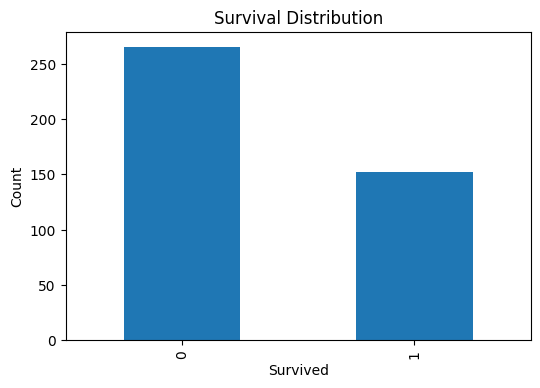

In [15]:
plt.figure(figsize=(6,4))

df["Survived"].value_counts().plot(
    kind="bar"
)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.savefig(
    "../reports/survival_distribution.png"
)

plt.show()

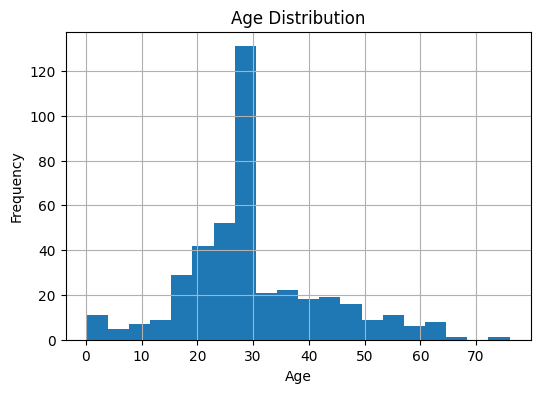

In [16]:
plt.figure(figsize=(6,4))

df["Age"].hist(
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig(
    "../reports/age_distribution.png"
)

plt.show()

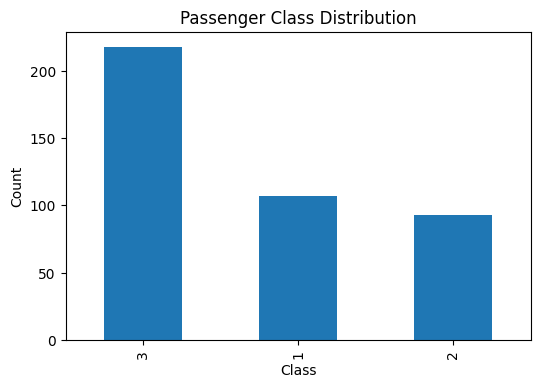

In [17]:
plt.figure(figsize=(6,4))

df["Pclass"].value_counts().plot(
    kind="bar"
)

plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig(
    "../reports/class_distribution.png"
)

plt.show()

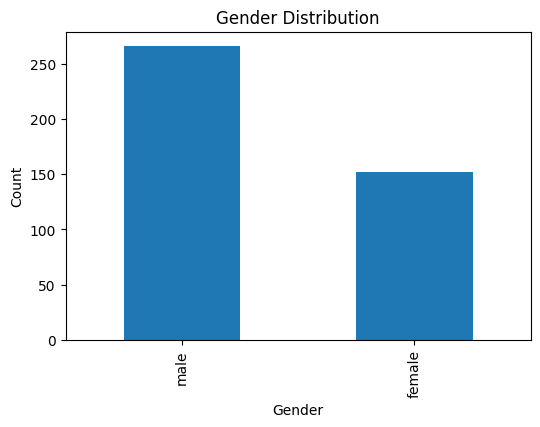

In [18]:
plt.figure(figsize=(6,4))

df["Sex"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig(
    "../reports/gender_distribution.png"
)

plt.show()

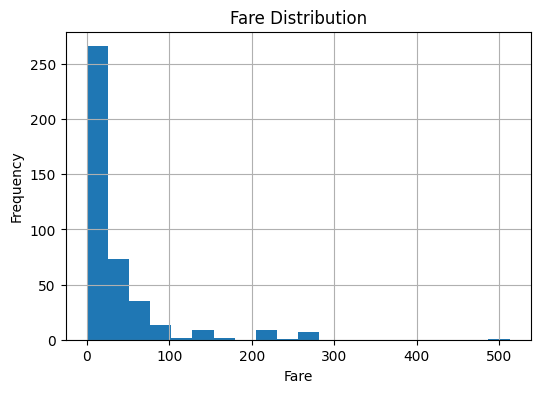

In [19]:
plt.figure(figsize=(6,4))

df["Fare"].hist(
    bins=20
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.savefig(
    "../reports/fare_distribution.png"
)

plt.show()

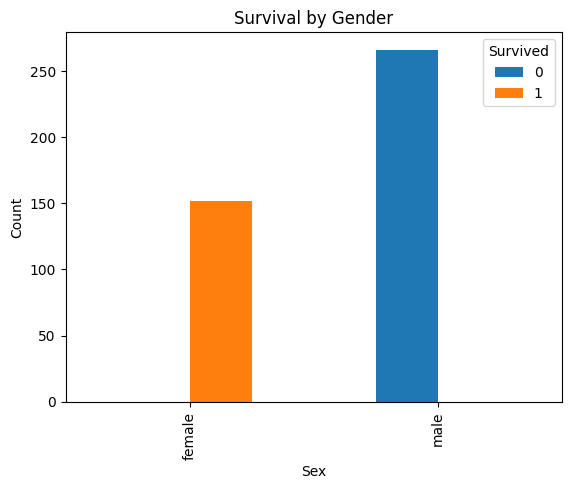

In [20]:
survival_gender = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

survival_gender.plot(kind="bar")

plt.title("Survival by Gender")
plt.ylabel("Count")

plt.savefig(
    "../reports/survival_by_gender.png"
)

plt.show()

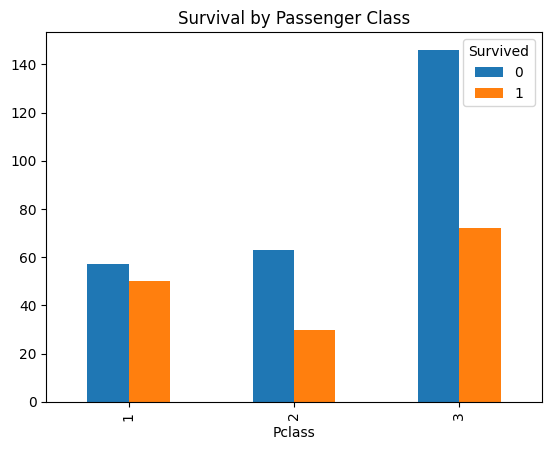

In [21]:
survival_class = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

survival_class.plot(kind="bar")

plt.title("Survival by Passenger Class")

plt.savefig(
    "../reports/survival_by_class.png"
)

plt.show()

In [22]:
numeric_cols = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Pclass",
    "Survived"
]

corr = df[numeric_cols].corr()

corr

,Age,Fare,SibSp,Parch,Pclass,Survived
Age,1.000000,0.342357,-0.071197,-0.043731,-0.467853,0.008035
Fare,0.342357,1.000000,0.171912,0.230325,-0.577313,0.192036
SibSp,-0.071197,0.171912,1.000000,0.306895,0.001087,0.099943
Parch,-0.043731,0.230325,0.306895,1.000000,0.018721,0.159120
Pclass,-0.467853,-0.577313,0.001087,0.018721,1.000000,-0.108615
Survived,0.008035,0.192036,0.099943,0.159120,-0.108615,1.000000
